# Run Any Kind of OLS Regression (ANOVA, GLM, etc.)

### Authors: Calvin Howard.

#### Last updated: July 6, 2023

Use this to run/test a statistical model (e.g., regression or T-tests) on a spreadsheet.

Notes:
- To best use this notebook, you should be familar with GLM design and Contrast Matrix design. See this webpage to get started:
[FSL's GLM page](https://fsl.fmrib.ox.ac.uk/fsl/fslwiki/GLM)

# 00 - Import CSV with All Data
**The CSV is expected to be in this format**
- ID and absolute paths to niftis are critical
```
+-----+----------------------------+--------------+--------------+--------------+
| ID  | Nifti_File_Path            | Covariate_1  | Covariate_2  | Covariate_3  |
+-----+----------------------------+--------------+--------------+--------------+
| 1   | /path/to/file1.nii.gz      | 0.5          | 1.2          | 3.4          |
| 2   | /path/to/file2.nii.gz      | 0.7          | 1.4          | 3.1          |
| 3   | /path/to/file3.nii.gz      | 0.6          | 1.5          | 3.5          |
| 4   | /path/to/file4.nii.gz      | 0.9          | 1.1          | 3.2          |
| ... | ...                        | ...          | ...          | ...          |
+-----+----------------------------+--------------+--------------+--------------+
```

Prep Output Direction

In [1]:
# Specify where you want to save your results to
out_dir = '/Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/acoe_reliability/results/ICC'

Import Data

In [2]:
# Specify the path to your CSV file containing NIFTI paths
input_csv_path = '/Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/acoe_reliability/master_list.csv'
sheet = None

In [3]:
from calvin_utils.permutation_analysis_utils.statsmodels_palm import CalvinStatsmodelsPalm
# Instantiate the PalmPrepararation class
cal_palm = CalvinStatsmodelsPalm(input_csv_path=input_csv_path, output_dir=out_dir, sheet=sheet)
# Call the process_nifti_paths method
data_df = cal_palm.read_and_display_data()
display(data_df)

,subject,use_for_icc,first_name,last_name,attempt_number,patient_uuid,physician_uuid,physician_email,score_method,Q2,...,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Total
0,1__,NaN,Calvin,Howard,1.0,NaN,NaN,president@cog-net.com,manual,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,3.0
1,1__,NaN,New,Patient,1.0,NaN,NaN,president@cog-net.com,manual,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1__,NaN,S,A,1.0,NaN,NaN,president@cog-net.com,manual,0.0,...,1.0,8.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,13.0
3,1_66943790bcf3d30e1cb8ec47_6fd1dff75ff64522bc2...,NaN,test,patient,1.0,66943790bcf3d30e1cb8ec47,6fd1dff75ff64522bc290c81d6a60e64,president@cog-net.com,auto,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,5.0,8.0
4,1_66943b86bcf3d30e1cb8ec65_,NaN,Dog,Cat,1.0,66943b86bcf3d30e1cb8ec65,NaN,president@cog-net.com,manual,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,8_67df54668d17a45bea171bd7_6fd1dff75ff64522bc2...,NaN,Calvin,Howard,8.0,67df54668d17a45bea171bd7,6fd1dff75ff64522bc290c81d6a60e64,president@cog-net.com,auto,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,5.0,17.0
144,8_67fc41178d17a45bea171db6_7fcb4363af48408aa3b...,NaN,Test3,Calvin,8.0,67fc41178d17a45bea171db6,7fcb4363af48408aa3b94fd683a8467b,neurotransmission@cog-net.com,auto,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
145,9_67fc41178d17a45bea171db6_7fcb4363af48408aa3b...,NaN,Test3,Calvin,9.0,67fc41178d17a45bea171db6,7fcb4363af48408aa3b94fd683a8467b,neurotransmission@cog-net.com,auto,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
146,9_6873d556a0af39468d167e8e_7fcb4363af48408aa3b...,NaN,Calvin,Howard,9.0,6873d556a0af39468d167e8e,7fcb4363af48408aa3b94fd683a8467b,neurotransmission@cog-net.com,auto,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,5.0


# 01 - Preprocess Your Data

**Handle NANs**
- Set drop_nans=True is you would like to remove NaNs from data
- Provide a column name or a list of column names to remove NaNs from

In [4]:
data_df.columns

Index(['subject', 'use_for_icc', 'first_name', 'last_name', 'attempt_number',
       'patient_uuid', 'physician_uuid', 'physician_email', 'score_method',
       'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12',
       'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Total'],
      dtype='object')

In [5]:
drop_list = ['Q3']

In [6]:
data_df = cal_palm.drop_nans_from_columns(columns_to_drop_from=drop_list)
display(data_df)

,subject,use_for_icc,first_name,last_name,attempt_number,patient_uuid,physician_uuid,physician_email,score_method,Q2,...,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Total
0,1__,NaN,Calvin,Howard,1.0,NaN,NaN,president@cog-net.com,manual,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,3.0
1,1__,NaN,New,Patient,1.0,NaN,NaN,president@cog-net.com,manual,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1__,NaN,S,A,1.0,NaN,NaN,president@cog-net.com,manual,0.0,...,1.0,8.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,13.0
3,1_66943790bcf3d30e1cb8ec47_6fd1dff75ff64522bc2...,NaN,test,patient,1.0,66943790bcf3d30e1cb8ec47,6fd1dff75ff64522bc290c81d6a60e64,president@cog-net.com,auto,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,5.0,8.0
4,1_66943b86bcf3d30e1cb8ec65_,NaN,Dog,Cat,1.0,66943b86bcf3d30e1cb8ec65,NaN,president@cog-net.com,manual,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,7_67fc41178d17a45bea171db6_7fcb4363af48408aa3b...,NaN,Test3,Calvin,7.0,67fc41178d17a45bea171db6,7fcb4363af48408aa3b94fd683a8467b,neurotransmission@cog-net.com,auto,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,5.0
143,8_67df54668d17a45bea171bd7_6fd1dff75ff64522bc2...,NaN,Calvin,Howard,8.0,67df54668d17a45bea171bd7,6fd1dff75ff64522bc290c81d6a60e64,president@cog-net.com,auto,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,5.0,17.0
144,8_67fc41178d17a45bea171db6_7fcb4363af48408aa3b...,NaN,Test3,Calvin,8.0,67fc41178d17a45bea171db6,7fcb4363af48408aa3b94fd683a8467b,neurotransmission@cog-net.com,auto,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
145,9_67fc41178d17a45bea171db6_7fcb4363af48408aa3b...,NaN,Test3,Calvin,9.0,67fc41178d17a45bea171db6,7fcb4363af48408aa3b94fd683a8467b,neurotransmission@cog-net.com,auto,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Drop Row Based on Value of Column**

Define the column, condition, and value for dropping rows
- column = 'your_column_name'
- condition = 'above'  # Options: 'equal', 'above', 'below'

In [7]:
data_df.columns

Index(['subject', 'use_for_icc', 'first_name', 'last_name', 'attempt_number',
       'patient_uuid', 'physician_uuid', 'physician_email', 'score_method',
       'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12',
       'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Total'],
      dtype='object')

Set the parameters for dropping rows

In [8]:
column = 'use_for_icc'  # The column you'd like to evaluate
condition = 'not'  # The condition to check ('equal', 'above', 'below', 'not')
value = 1 # The value to drop if found

In [9]:
data_df, other_df = cal_palm.drop_rows_based_on_value(column, condition, value)
display(data_df)

,subject,use_for_icc,first_name,last_name,attempt_number,patient_uuid,physician_uuid,physician_email,score_method,Q2,...,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Total
8,1_66d72cf25c4020b0e5390fb1_,1.0,test_calvin,howard,1.0,66d72cf25c4020b0e5390fb1,NaN,president@cog-net.com,manual,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1_66d72cf25c4020b0e5390fb1_6fd1dff75ff64522bc2...,1.0,test_calvin,howard,1.0,66d72cf25c4020b0e5390fb1,6fd1dff75ff64522bc290c81d6a60e64,president@cog-net.com,auto,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,5.0,7.0
10,1_66d89579f97a835171abcdef_,1.0,t,t,1.0,66d89579f97a835171abcdef,NaN,president@cog-net.com,manual,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,1_66d89579f97a835171abcdef_6fd1dff75ff64522bc2...,1.0,t,t,1.0,66d89579f97a835171abcdef,6fd1dff75ff64522bc290c81d6a60e64,president@cog-net.com,auto,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,5.0,7.0
12,1_66d90adcea78dcfd2caad80d_,1.0,Auguste,Deter,1.0,66d90adcea78dcfd2caad80d,NaN,president@cog-net.com,manual,0.0,...,0.0,7.0,0.0,0.0,2.0,4.0,3.0,1.0,1.0,35.0
13,1_66d90adcea78dcfd2caad80d_6fd1dff75ff64522bc2...,1.0,Auguste,Deter,1.0,66d90adcea78dcfd2caad80d,6fd1dff75ff64522bc290c81d6a60e64,president@cog-net.com,auto,0.0,...,0.0,7.0,0.0,0.0,2.0,4.0,3.0,0.0,5.0,33.0
17,1_67155f1184a5e5d790727d79_,1.0,test,Testipatient,1.0,67155f1184a5e5d790727d79,NaN,president@cog-net.com,manual,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,3.0
18,1_67155f1184a5e5d790727d79_6fd1dff75ff64522bc2...,1.0,Test,Testipatient,1.0,67155f1184a5e5d790727d79,6fd1dff75ff64522bc290c81d6a60e64,president@cog-net.com,auto,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,5.0,8.0
19,1_6733f2ca2a02daf060764d86_,1.0,Angela,Bader,1.0,6733f2ca2a02daf060764d86,NaN,president@cog-net.com,manual,10.0,...,0.0,0.0,4.0,0.0,8.0,0.0,0.0,0.0,5.0,30.0
20,1_6733f2ca2a02daf060764d86_6fd1dff75ff64522bc2...,1.0,Angela,Bader,1.0,6733f2ca2a02daf060764d86,6fd1dff75ff64522bc290c81d6a60e64,president@cog-net.com,auto,0.0,...,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,5.0,13.0


**Standardize Data**
- Enter Columns you Don't want to standardize into a list

In [10]:
# Remove anything you don't want to standardize
# cols_not_to_standardize = None # ['Z_Scored_Percent_Cognitive_Improvement_By_Origin_Group', 'Z_Scored_Subiculum_T_By_Origin_Group_'] #['Age']

In [11]:
# data_df = cal_palm.standardize_columns(cols_not_to_standardize)
# data_df

In [12]:
# for col in data_df.columns:
#     if 'CSF' and 'eh' not in col:
#         data_df[col] = data_df[col] * -1

Melt Df

# 02 - Derive ICCs

In [13]:
columns_to_compare = ['Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9',
       'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Total']
rater_column = 'score_method'
y_label = 'Question'

Combined ICC Results: 
  {'Q2': (-0.08571428571428572, -0.54, 0.41, 0.6280467289733521), 'Q3': (0.41287878787878785, -0.07, 0.74, 0.04575892077330412), 'Q4': (0.423076923076923, -0.06, 0.75, 0.041500831691462126), 'Q5': (0.4444444444444444, -0.03, 0.76, 0.033524846125486604), 'Q6': (0.7611424719858455, 0.45, 0.91, 0.00013363763301597846), 'Q7': (0.869695957233545, 0.67, 0.95, 1.5452659176038754e-06), 'Q8': (0.7068021892103206, 0.35, 0.89, 0.0005638553553946157), 'Q9': (-0.25514403292181065, -0.65, 0.25, 0.8404794638905718), 'Q10': (-0.2561576354679803, -0.65, 0.25, 0.8414749895641851), 'Q11': (0.9145299145299145, 0.78, 0.97, 6.187983842372563e-08), 'Q12': (0.3574128517429651, -0.14, 0.71, 0.0745367454996327), 'Q13': (0.7954279776594363, 0.52, 0.92, 4.3806550957859726e-05), 'Q14': (-0.2489694971145919, -0.65, 0.26, 0.8343355581748004), 'Q15': (0.004499437570303696, -0.47, 0.48, 0.4908504303068218), 'Q16': (0.281947261663286, -0.22, 0.67, 0.13062774279837008), 'Q17': (0.8905908096280087,

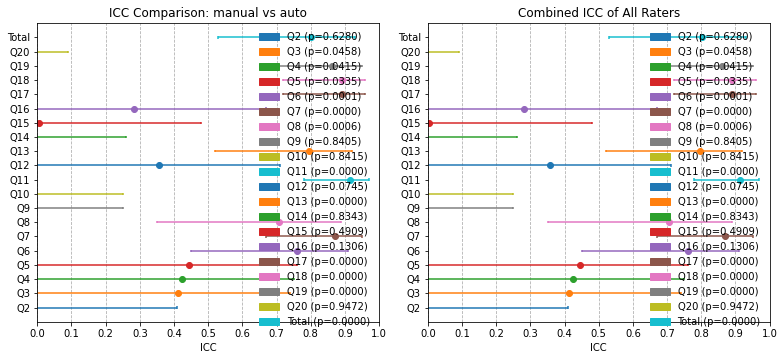

{('manual',
  'auto'): {'Q2': (-0.08571428571428572,
   -0.54,
   0.41,
   0.6280467289733521), 'Q3': (0.41287878787878785,
   -0.07,
   0.74,
   0.04575892077330412), 'Q4': (0.423076923076923,
   -0.06,
   0.75,
   0.041500831691462126), 'Q5': (0.4444444444444444,
   -0.03,
   0.76,
   0.033524846125486604), 'Q6': (0.7611424719858455,
   0.45,
   0.91,
   0.00013363763301597846), 'Q7': (0.869695957233545,
   0.67,
   0.95,
   1.5452659176038754e-06), 'Q8': (0.7068021892103206,
   0.35,
   0.89,
   0.0005638553553946157), 'Q9': (-0.25514403292181065,
   -0.65,
   0.25,
   0.8404794638905718), 'Q10': (-0.2561576354679803,
   -0.65,
   0.25,
   0.8414749895641851), 'Q11': (0.9145299145299145,
   0.78,
   0.97,
   6.187983842372563e-08), 'Q12': (0.3574128517429651,
   -0.14,
   0.71,
   0.0745367454996327), 'Q13': (0.7954279776594363,
   0.52,
   0.92,
   4.3806550957859726e-05), 'Q14': (-0.2489694971145919,
   -0.65,
   0.26,
   0.8343355581748004), 'Q15': (0.004499437570303696,
   -0.47

In [14]:
from calvin_utils.statistical_utils.icc_analysis import ICCAnalysis
# Initialize the class
analysis = ICCAnalysis()
# Orchestrate multiple iterations of t-tests and plot boxplots
analysis.orchestrate_icc_analysis(data_df, rater_column, columns_to_compare, outdir=out_dir, icc="ICC(1,1)")